loading dataset


In [1]:
import nibabel as nib
import numpy as np

path = r"C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\001\001_cbct\001_cbct.nii"

scan = nib.load(path)
data = scan.get_fdata()

print(data.shape)

(604, 604, 412)


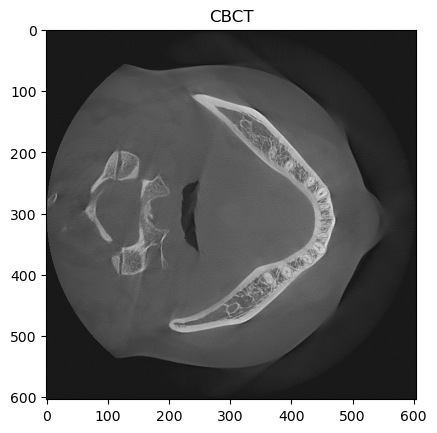

In [2]:
import matplotlib.pyplot as plt

plt.imshow(data[:,:,100], cmap='gray')
plt.title("CBCT")
plt.show()

In [3]:
import os
import nibabel as nib

dataset_path = r"C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1"

scans = []

for patient in os.listdir(dataset_path):

    cbct_folder = os.path.join(dataset_path, patient, patient + "_cbct")

    if os.path.isdir(cbct_folder):

        for file in os.listdir(cbct_folder):

            if file.endswith(".nii"):

                path = os.path.join(cbct_folder, file)

                scan = nib.load(path)

                scans.append(scan)   

                print("Loaded:", path)

print("Total scans loaded:", len(scans))

Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\001\001_cbct\001_cbct.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\002\002_cbct\002_cbct.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\003\003_cbct\003_cbct1.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\004\004_cbct\004_cbct.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\005\005_cbct\005_cbct1.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\006\006_cbct\006_cbct.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\007\007_cbct\007_cbct1.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\008\008_cbct\008_cbct1.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\009\009_cbct\009_cbct.nii
Loaded: C:\Users\chara\OneDrive\Desktop\projects\cbct proj\teeth_data1\010\010_cbct\010_cbct1.nii
Loaded: C:\Users\chara\On

data preprocessing

slicing

In [4]:
import numpy as np

images = []

for scan in scans:

    data = scan.get_fdata()

    for i in range(data.shape[2]):

        slice_img = data[:,:,i]

        images.append(slice_img)

print("Total slices:", len(images))

Total slices: 8652


Normalize pixel values and resize

In [5]:
import numpy as np
import cv2

processed_images = []

for scan in scans:

    data = scan.get_fdata()

    for i in range(data.shape[2]):

        slice_img = data[:,:,i]

        slice_img = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min())

        
        slice_img = cv2.resize(slice_img,(256,256))

        processed_images.append(slice_img)

print("Total slices:", len(processed_images))

Total slices: 8652


convert to numpy

In [9]:
images = np.array(processed_images, dtype="float32")

images = images.reshape(-1,256,256,1)

print(images.shape)

(8652, 256, 256, 1)


train_test_split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (6921, 256, 256, 1)
Test: (1731, 256, 256, 1)


generator

In [11]:
import numpy as np

def data_generator(images, batch_size=4):

    while True:

        idx = np.random.randint(0, len(images), batch_size)

        X = images[idx]

        y = np.random.randint(0,2,batch_size)

        yield X, y

In [12]:
train_gen = data_generator(X_train, batch_size=4)
val_gen = data_generator(X_test, batch_size=4)

model

create model

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(256,256,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

model.summary()

c:\Users\chara\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,529 (56.60 MB)

 Trainable params: 14,838,529 (56.60 MB)

 Non-trainable params: 0 (0.00 B)

compile model

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Create Dummy Labels (temporary)

In [15]:
import numpy as np

y_train = np.random.randint(0,2,len(X_train))
y_test = np.random.randint(0,2,len(X_test))

train model

In [18]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=200,
    validation_steps=50,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.5138 - loss: 0.6931 - val_accuracy: 0.4900 - val_loss: 0.6935
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - accuracy: 0.5163 - loss: 0.6929 - val_accuracy: 0.4700 - val_loss: 0.6942
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - accuracy: 0.5138 - loss: 0.6930 - val_accuracy: 0.5150 - val_loss: 0.6928
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.4963 - loss: 0.6935 - val_accuracy: 0.4700 - val_loss: 0.6940
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - accuracy: 0.4963 - loss: 0.6935 - val_accuracy: 0.4750 - val_loss: 0.6938
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - accuracy: 0.5188 - loss: 0

save the model

In [19]:
model.save("cbct_unet_model.h5")

load saved model

In [20]:
from tensorflow.keras.models import load_model

model = load_model("cbct_unet_model.h5")

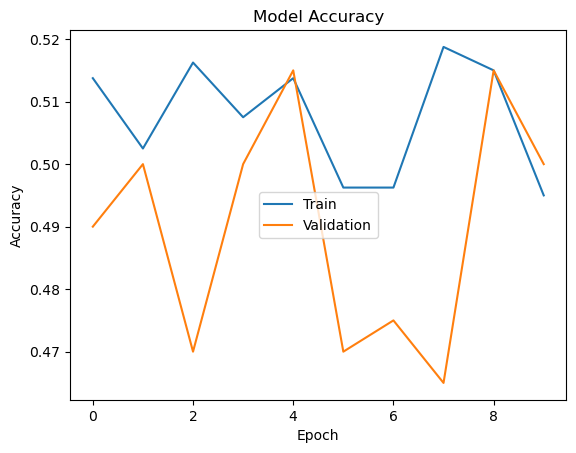

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

prediction

In [30]:
pred = model.predict(X_test[:5])

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.49307114]
 [0.49307114]
 [0.49307114]
 [0.49307114]
 [0.49307114]]


visual

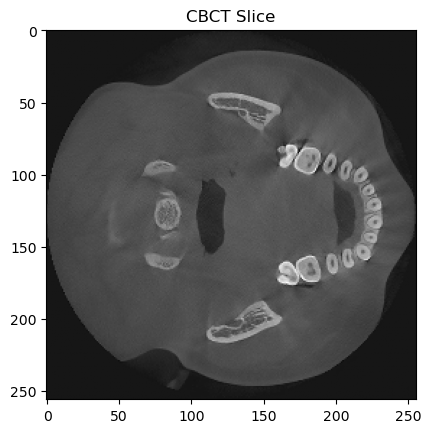

Prediction: [0.49307114]


In [23]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0].squeeze(), cmap="gray")
plt.title("CBCT Slice")
plt.show()

print("Prediction:", pred[0])

bone volume

In [ ]:
import numpy as np

slice_img = X_test[0].squeeze()

bone_pixels = np.sum(slice_img > 0.5)

voxel_volume = 0.4 * 0.4 * 0.4   

bone_volume = bone_pixels * voxel_volume

print("Bone Volume:", bone_volume, "mm³")

Bone Volume: 140.35200000000003 mm³


In [25]:
bone_density = slice_img[slice_img > 0.5].mean()

print("Bone Density:", bone_density)

Bone Density: 0.58578205


In [26]:
if pred[0][0] > 0.5:
    print("Implant Feasible: YES")
else:
    print("Implant Feasible: NO")

Implant Feasible: NO
